_Note: most of this code was generated using Gemini._

# EDA

In the folllowing code block, I plot all the features in 'Combined_Arizona_Climate_Flow_Demand.csv' against each other.

Pairplot successfully created and saved!


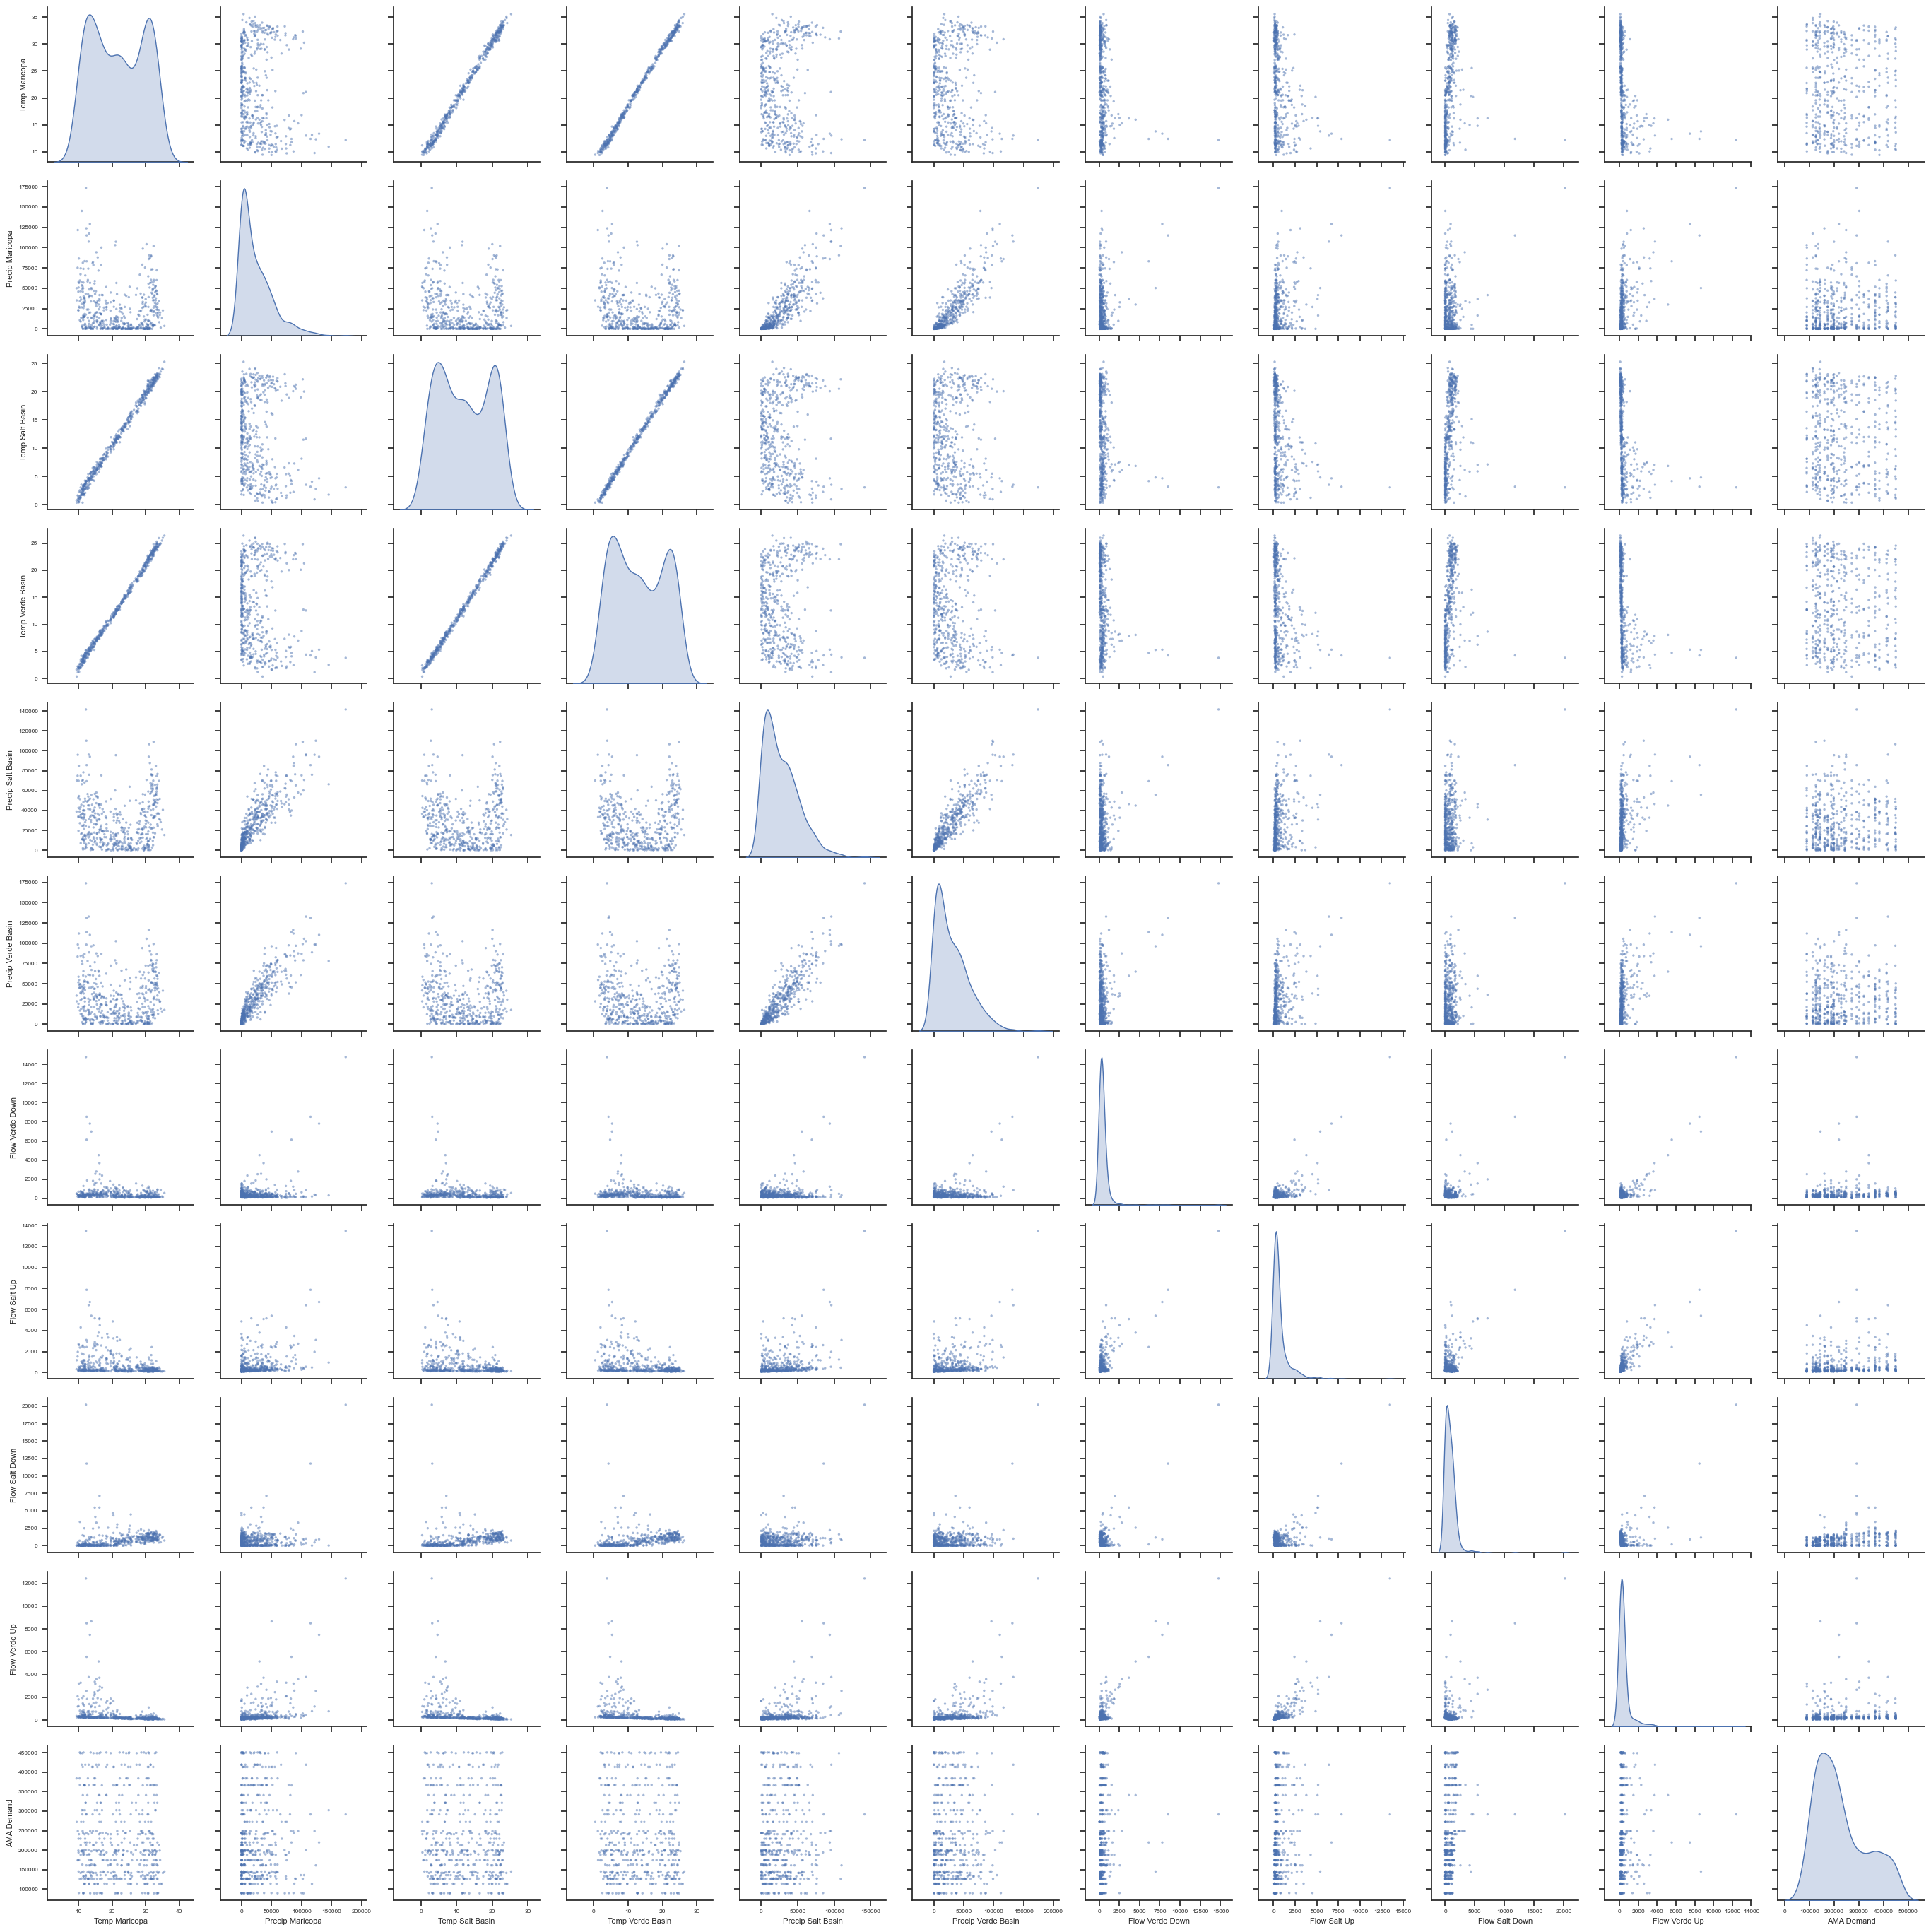

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the master dataset
df = pd.read_csv('../Data/FormattedData/Havi/Combined_Arizona_Climate_Flow_Demand.csv')

# 2. Drop the text 'time' column and remove rows with missing records 
# This restricts the data to a dense window (1985-2024) where all variables overlap
df_numeric = df.drop(columns=['time']).dropna()

# 3. Clean up column names so axis labels don't bunch up or overlap
rename_dict = {
    'temp_maricopa': 'Temp Maricopa',
    'precip_maricopa': 'Precip Maricopa',
    'Temp_Salt': 'Temp Salt Basin',
    'Temp_Verde': 'Temp Verde Basin',
    'Precip_Salt': 'Precip Salt Basin',
    'Precip_Verde': 'Precip Verde Basin',
    'flow_verde_downstream': 'Flow Verde Down',
    'flow_salt_upstream': 'Flow Salt Up',
    'flow_salt_downstream': 'Flow Salt Down',
    'flow_verde_upstream': 'Flow Verde Up',
    'ama_quantity': 'AMA Demand'
}
df_numeric = df_numeric.rename(columns=rename_dict)

# 4. Set visual style and generate pairplot matrix
sns.set_theme(style="ticks")

# Using small markers (s=6) and transparency (alpha=0.5) to keep the 121 subplots clear
g = sns.pairplot(
    df_numeric, 
    diag_kind="kde",
    plot_kws={"s": 6, "alpha": 0.5, "edgecolor": "none"},
    diag_kws={"fill": True}
)

# 5. Fine-tune text sizing for maximum readability
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(8)
        ax.yaxis.label.set_size(8)
        ax.tick_params(labelsize=6)

plt.tight_layout()

# 6. Save the matrix plot as a high-resolution PNG
g.savefig('Arizona_Features_Pairplot.png', dpi=200)
print("Pairplot successfully created and saved!")

In the following block, I plot all the features in 'Combined_Arizona_Climate_Flow_Demand.csv' against each other, except I take the log of all river flow data and of the AMA supply data.

Log-transformed pairplot successfully saved!


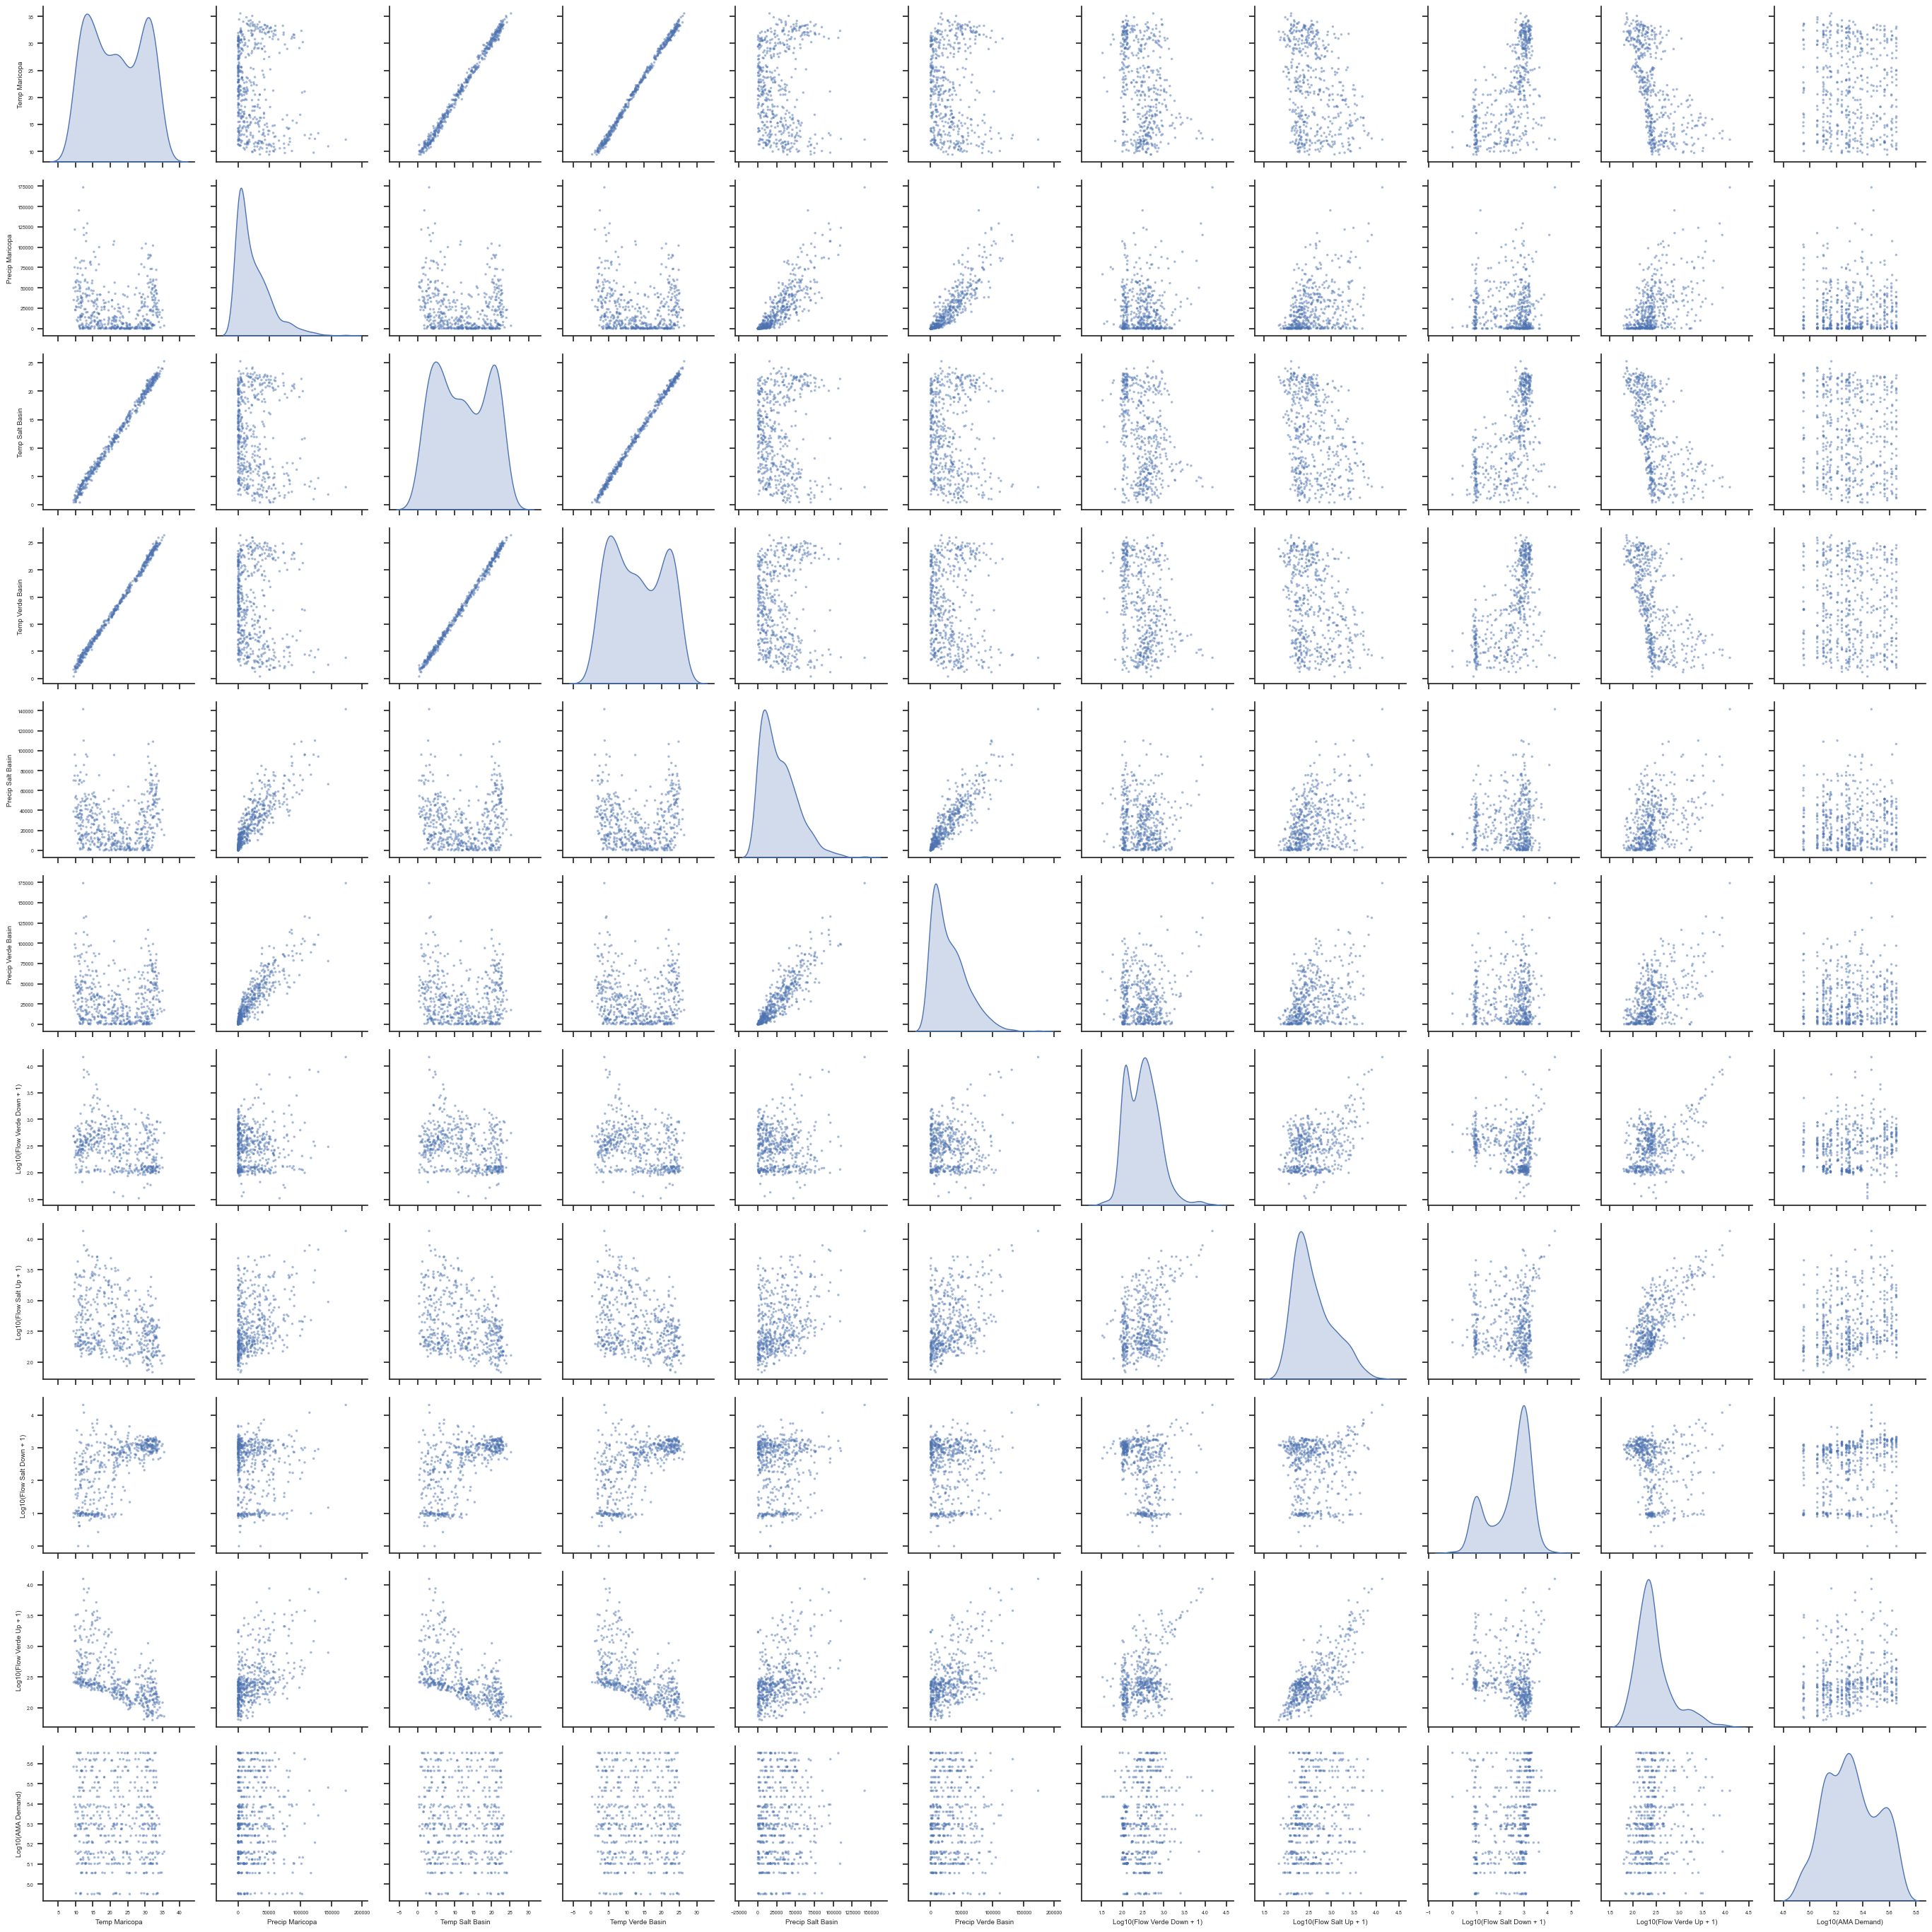

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the combined dataset
df = pd.read_csv('../Data/FormattedData/Havi/Combined_Arizona_Climate_Flow_Demand.csv')

# 2. Extract numeric columns and drop missing values for matching timelines (1985-2024)
df_numeric = df.drop(columns=['time']).dropna().copy()

# 3. Identify targets for log-transformation
flow_cols = ['flow_verde_downstream', 'flow_salt_upstream', 'flow_salt_downstream', 'flow_verde_upstream']
demand_col = 'ama_quantity'

# 4. Apply Log10(x + 1) to streamflow gauges to handle 0 cfs values safely
for col in flow_cols:
    df_numeric[col] = np.log10(df_numeric[col] + 1)

# 5. Apply standard Log10 to the water demand column
df_numeric[demand_col] = np.log10(df_numeric[demand_col])

# 6. Rename columns to clearly state the mathematical transformation applied
rename_dict = {
    'temp_maricopa': 'Temp Maricopa',
    'precip_maricopa': 'Precip Maricopa',
    'Temp_Salt': 'Temp Salt Basin',
    'Temp_Verde': 'Temp Verde Basin',
    'Precip_Salt': 'Precip Salt Basin',
    'Precip_Verde': 'Precip Verde Basin',
    'flow_verde_downstream': 'Log10(Flow Verde Down + 1)',
    'flow_salt_upstream': 'Log10(Flow Salt Up + 1)',
    'flow_salt_downstream': 'Log10(Flow Salt Down + 1)',
    'flow_verde_upstream': 'Log10(Flow Verde Up + 1)',
    'ama_quantity': 'Log10(AMA Demand)'
}
df_numeric = df_numeric.rename(columns=rename_dict)

# 7. Configure Seaborn theme aesthetics
sns.set_theme(style="ticks")

# 8. Render the pairplot grid matrix
g = sns.pairplot(
    df_numeric, 
    diag_kind="kde",
    plot_kws={"s": 6, "alpha": 0.5, "edgecolor": "none"},
    diag_kws={"fill": True}
)

# 9. Adjust labels and tick text sizes to ensure they do not truncate or overlap
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(7)
        ax.yaxis.label.set_size(7)
        ax.tick_params(labelsize=5)

plt.tight_layout()

# 10. Save the resulting log-scaled plot to disk
g.savefig('Arizona_Log_Features_Pairplot.png', dpi=200)
print("Log-transformed pairplot successfully saved!")

In the following block, I plot monthly Salt river downstream flow data against time.

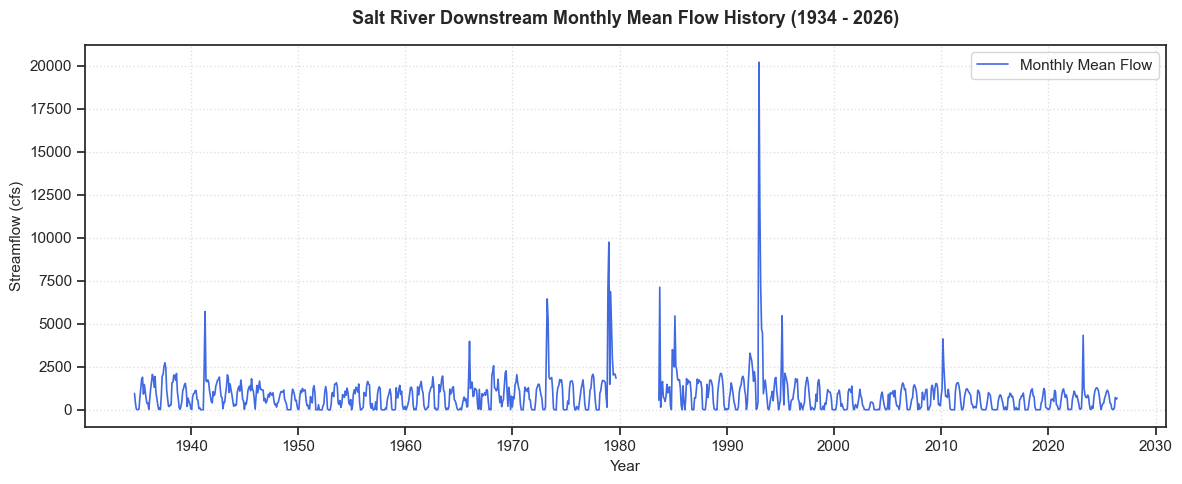

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the specific streamlined downstream dataset
df = pd.read_csv('../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv')

# 2. Convert timestamps into proper datetime format and sort chronologically
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# 3. Create a clean subplot layout
fig, ax = plt.subplots(figsize=(12, 5))

# 4. Generate the time-series line plot
ax.plot(df['time'], df['value'], color='royalblue', linewidth=1.2, label='Monthly Mean Flow')

# 5. Apply readable labels, titles, and structural formatting
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Streamflow (cfs)', fontsize=11)
ax.set_title('Salt River Downstream Monthly Mean Flow History (1934 - 2026)', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

# 6. Adjust padding and save to your workspace as a high-resolution PNG
plt.tight_layout()
plt.savefig('Salt_River_Downstream_Flow_Time_Series.png', dpi=200)

# Baseline Models for River Flow

In the following block, I demostrate a 5-fold cross-validation for the data in 'Combined_Arizona_Climate_Flow_Demand.csv'.

In [6]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

# 1. Load the dataset and drop the water demand data
df = pd.read_csv('../Data/FormattedData/Havi/Combined_Arizona_Climate_Flow_Demand.csv')
df['time'] = pd.to_datetime(df['time'])

# Sort chronologically and drop missing values (keeps 1934 onward)
df_clean = df.drop(columns=['ama_quantity']).dropna().sort_values('time').reset_index(drop=True)

# 2. Chop off the Ultimate Test Set (2015 to Mid-2026)
test_cutoff_date = pd.to_datetime('2015-01-01')

df_cv_pool = df_clean[df_clean['time'] < test_cutoff_date].copy()
df_ultimate_test = df_clean[df_clean['time'] >= test_cutoff_date].copy()

# 3. Separate features (X) and target (y) for both pools
X_cv_pool = df_cv_pool.drop(columns=['time', 'flow_salt_downstream'])
y_cv_pool = df_cv_pool['flow_salt_downstream']

X_ultimate_test = df_ultimate_test.drop(columns=['time', 'flow_salt_downstream'])
y_ultimate_test = df_ultimate_test['flow_salt_downstream']

print(f"Total historical pool for Cross-Validation (1934-2014): {len(df_cv_pool)} months")
print(f"Total volume in Ultimate Test Set (2015-2026):        {len(df_ultimate_test)} months\n")

# 4. Execute 5-Fold TimeSeriesSplit ONLY on the historical pool
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, val_index) in enumerate(tscv.split(X_cv_pool)):
    X_train, X_val = X_cv_pool.iloc[train_index], X_cv_pool.iloc[val_index]
    y_train, y_val = y_cv_pool.iloc[train_index], y_cv_pool.iloc[val_index]
    
    print(f"--- Fold {fold + 1} ---")
    print(f"  Train Window Size: {len(train_index)} months")
    print(f"  Val Window Size:   {len(val_index)} months")
    print(f"  Val Rows Map to Indices: {val_index[0]} to {val_index[-1]}\n")

print("=========================================================")
print("Model selection and tuning happens inside the loop above.")
print("Once chosen, evaluate the final champion model ONCE against the Ultimate Test Set:")
print(f"Ultimate Test Features Shape: {X_ultimate_test.shape}")

Total historical pool for Cross-Validation (1934-2014): 786 months
Total volume in Ultimate Test Set (2015-2026):        137 months

--- Fold 1 ---
  Train Window Size: 131 months
  Val Window Size:   131 months
  Val Rows Map to Indices: 131 to 261

--- Fold 2 ---
  Train Window Size: 262 months
  Val Window Size:   131 months
  Val Rows Map to Indices: 262 to 392

--- Fold 3 ---
  Train Window Size: 393 months
  Val Window Size:   131 months
  Val Rows Map to Indices: 393 to 523

--- Fold 4 ---
  Train Window Size: 524 months
  Val Window Size:   131 months
  Val Rows Map to Indices: 524 to 654

--- Fold 5 ---
  Train Window Size: 655 months
  Val Window Size:   131 months
  Val Rows Map to Indices: 655 to 785

Model selection and tuning happens inside the loop above.
Once chosen, evaluate the final champion model ONCE against the Ultimate Test Set:
Ultimate Test Features Shape: (137, 9)


In the following block I run a seasonal average baseline model on the monthly average Salt River downstream data. This generates 'Salt_River_Seasonal_Baseline_Performance.png'.

Historical Train Pool (1934-2014) -> MAE: 515.2 cfs, RMSE: 1130.1 cfs, R²: 0.11
Ultimate Test Set     (2015-2023) -> MAE: 454.0 cfs, RMSE: 571.8 cfs, R²: -0.18


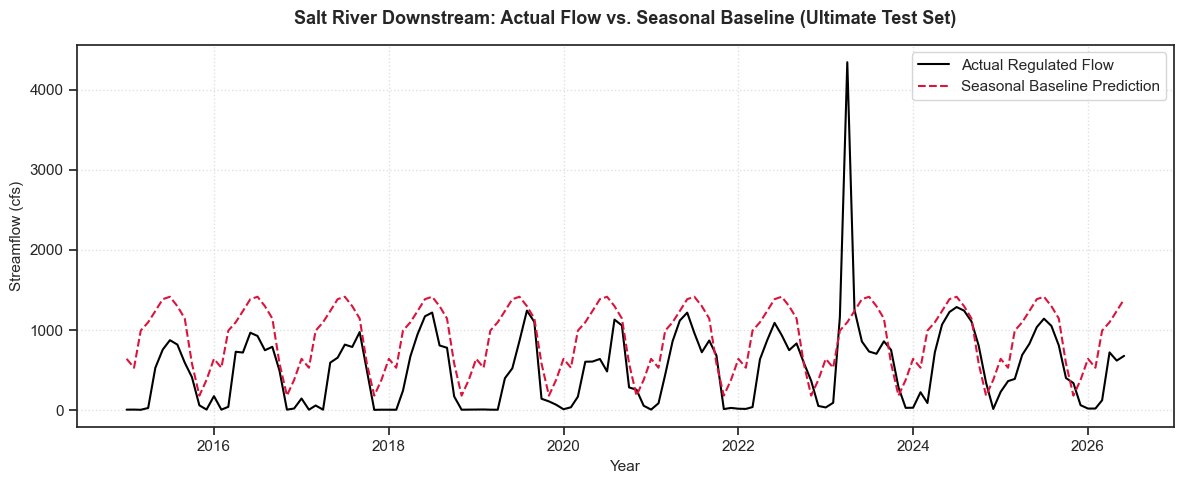

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the data and strip missing values
df = pd.read_csv('../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.dropna().sort_values('time').reset_index(drop=True)

# Extract the calendar month integer (1 to 12)
df['month'] = df['time'].dt.month

# 2. Chronological split: Historical Pool vs Ultimate Test Set
train_pool = df[df['time'] < '2015-01-01'].copy()
test_pool = df[df['time'] >= '2015-01-01'].copy()

# 3. Calculate seasonal averages strictly from the training period
seasonal_averages = train_pool.groupby('month')['value'].mean().to_dict()

# 4. Generate baseline predictions by mapping the monthly averages
train_pool['pred'] = train_pool['month'].map(seasonal_averages)
test_pool['pred'] = test_pool['month'].map(seasonal_averages)

# 5. Calculate validation metrics
def evaluate(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    return mae, rmse, r2

train_mae, train_rmse, train_r2 = evaluate(train_pool['value'], train_pool['pred'])
test_mae, test_rmse, test_r2 = evaluate(test_pool['value'], test_pool['pred'])

print(f"Historical Train Pool (1934-2014) -> MAE: {train_mae:.1f} cfs, RMSE: {train_rmse:.1f} cfs, R²: {train_r2:.2f}")
print(f"Ultimate Test Set     (2015-2023) -> MAE: {test_mae:.1f} cfs, RMSE: {test_rmse:.1f} cfs, R²: {test_r2:.2f}")

# 6. Plot actual flows vs the seasonal baseline over the ultimate test set
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_pool['time'], test_pool['value'], color='black', label='Actual Regulated Flow', linewidth=1.5)
ax.plot(test_pool['time'], test_pool['pred'], color='crimson', linestyle='--', label='Seasonal Baseline Prediction', linewidth=1.5)

# Label formatting
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Streamflow (cfs)', fontsize=11)
ax.set_title('Salt River Downstream: Actual Flow vs. Seasonal Baseline (Ultimate Test Set)', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Salt_River_Seasonal_Baseline_Performance.png', dpi=200)

In the next block I run a seasonal random walk baseline model for the monthly average Salt River downstream data. This generates 'Salt_River_Seasonal_Random_Walk_Performance.png'. Note that we use 5-fold cross-validation here.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# 1. Load the data and handle chronological alignment
df = pd.read_csv('MonthlyFlow_SaltDownstream_Streamlined.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Reindex to a continuous month-by-month grid to ensure a 12-month shift aligns perfectly
df.set_index('time', inplace=True)
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')
df = df.reindex(full_idx)
df.index.name = 'time'
df.reset_index(inplace=True)

# 2. Apply Seasonal Random Walk formula: Shift observations forward by 12 months
df['pred'] = df['value'].shift(12)

# Drop missing rows (the first 12 months have no historical lag to look back to)
df_eval = df.dropna().copy()

# 3. Chronological Train-Test Split
train_pool = df_eval[df_eval['time'] < '2015-01-01'].copy()
test_pool = df_eval[df_eval['time'] >= '2015-01-01'].copy()

# 4. Evaluate overall Train Pool vs Ultimate Test Set
def evaluate(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    return mae, rmse, r2

train_mae, train_rmse, train_r2 = evaluate(train_pool['value'], train_pool['pred'])
test_mae, test_rmse, test_r2 = evaluate(test_pool['value'], test_pool['pred'])

print(f"Historical Train Pool (1935-2014) -> MAE: {train_mae:.1f} cfs, RMSE: {train_rmse:.1f} cfs, R²: {train_r2:.2f}")
print(f"Ultimate Test Set     (2015-2023) -> MAE: {test_mae:.1f} cfs, RMSE: {test_rmse:.1f} cfs, R²: {test_r2:.2f}\n")

# 5. Run 5-Fold TimeSeriesSplit Cross-Validation on the Historical Pool
tscv = TimeSeriesSplit(n_splits=5)
fold_maes = []
fold_r2s = []

print("5-Fold Cross-Validation Breakdown:")
for fold, (train_index, val_index) in enumerate(tscv.split(train_pool)):
    val_fold = train_pool.iloc[val_index]
    mae = mean_absolute_error(val_fold['value'], val_fold['pred'])
    r2 = r2_score(val_fold['value'], val_fold['pred'])
    fold_maes.append(mae)
    fold_r2s.append(r2)
    print(f"  Fold {fold+1}: Validation MAE = {mae:.2f} cfs, Validation R² = {r2:.2f}")

print(f"\nAverage Cross-Validation MAE: {np.mean(fold_maes):.2f} cfs")
print(f"Average Cross-Validation R²:  {np.mean(fold_r2s):.2f}")

# 6. Plot actual values vs the seasonal random walk baseline
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_pool['time'], test_pool['value'], color='black', label='Actual Regulated Flow', linewidth=1.5)
ax.plot(test_pool['time'], test_pool['pred'], color='darkorange', linestyle='--', label='Seasonal Random Walk Prediction', linewidth=1.5)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Streamflow (cfs)', fontsize=11)
ax.set_title('Salt River Downstream: Actual Flow vs. Seasonal Random Walk Baseline (Ultimate Test Set)', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Salt_River_Seasonal_Random_Walk_Performance.png', dpi=200)

In the next block I run a seasonal random walk baseline model for the monthly average Salt River downstream data. This generates 'Salt_River_Seasonal_Random_Walk_Performance.png'. I do not use cross-validation.

--- Time-Series Data Split Summary (2015 Cutoff) ---
Train Split: 1935-10-01 to 2014-12-01 (892 months)
  - MAE  : 558.33 cfs
  - RMSE : 1438.18 cfs
  - R²   : -0.4478

Test Split: 2015-01-01 to 2026-06-01 (138 months)
  - MAE  : 248.32 cfs
  - RMSE : 526.22 cfs
  - R²   : -0.0032



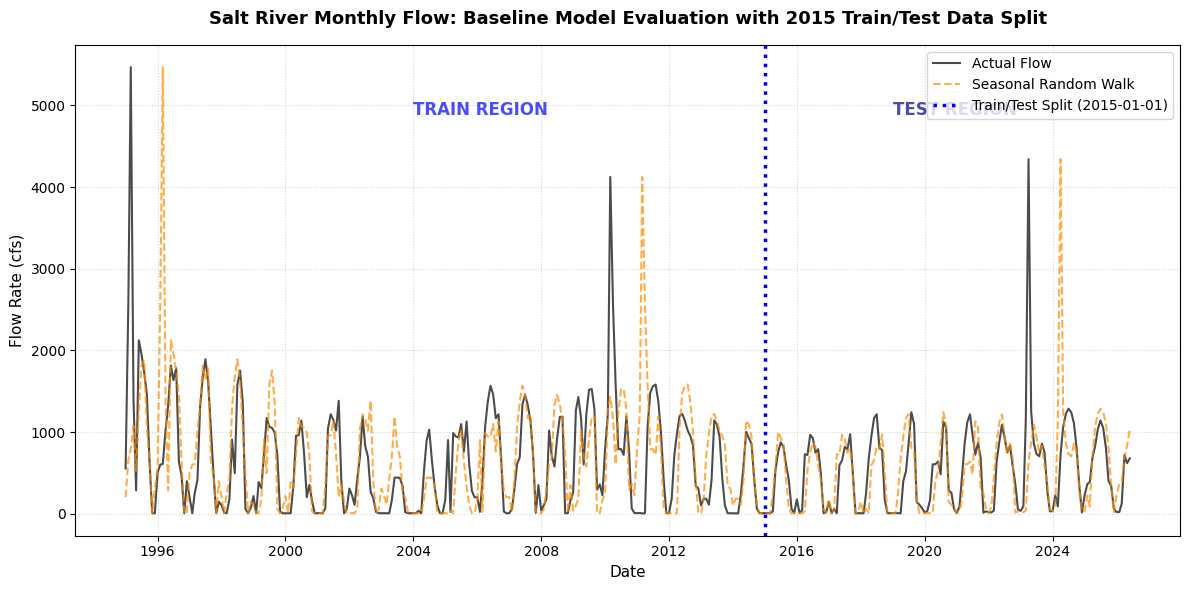

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the streamlined monthly streamflow dataset
df_monthly = pd.read_csv('../Data/FormattedData/Havi/MonthlyFlow_SaltDownstream_Streamlined.csv')
df_monthly['time'] = pd.to_datetime(df_monthly['time'])
df_monthly = df_monthly.sort_values('time').reset_index(drop=True)

# 2. Implement 12-Month Seasonal Lag (naive calendar year prediction)
df_monthly['predicted_value'] = df_monthly['value'].shift(12)

# Remove rows lacking historical lags or containing missing data segments
df_eval = df_monthly.dropna(subset=['value', 'predicted_value']).copy()

# 3. Apply the updated Chronological Data Split (Cutoff Date: January 1, 2015)
split_date = '2015-01-01'

train_df = df_eval[df_eval['time'] < split_date]
test_df = df_eval[df_eval['time'] >= split_date]

# 4. Calculate performance metrics for both slices
metrics_2015 = {}
for name, split in [('Train', train_df), ('Test', test_df)]:
    metrics_2015[name] = {
        'MAE': mean_absolute_error(split['value'], split['predicted_value']),
        'RMSE': np.sqrt(mean_squared_error(split['value'], split['predicted_value'])),
        'R2': r2_score(split['value'], split['predicted_value']),
        'Start': split['time'].min().strftime('%Y-%m-%d'),
        'End': split['time'].max().strftime('%Y-%m-%d'),
        'Rows': len(split)
    }

# Print the Data Split Summary
print("--- Time-Series Data Split Summary (2015 Cutoff) ---")
for name in ['Train', 'Test']:
    print(f"{name} Split: {metrics_2015[name]['Start']} to {metrics_2015[name]['End']} ({metrics_2015[name]['Rows']} months)")
    print(f"  - MAE  : {metrics_2015[name]['MAE']:.2f} cfs")
    print(f"  - RMSE : {metrics_2015[name]['RMSE']:.2f} cfs")
    print(f"  - R²   : {metrics_2015[name]['R2']:.4f}\n")

# 5. Create a plot showing the new data distribution split
fig, ax = plt.subplots(figsize=(12, 6))

# Slice from 1995 onwards for visual clarity
df_plot = df_eval[df_eval['time'] >= '1995-01-01']

ax.plot(df_plot['time'], df_plot['value'], color='black', alpha=0.7, label='Actual Flow')
ax.plot(df_plot['time'], df_plot['predicted_value'], color='darkorange', alpha=0.7, linestyle='--', label='Seasonal Random Walk')

# Draw the 2015 vertical split line
ax.axvline(pd.to_datetime(split_date), color='blue', linestyle=':', linewidth=2.5, label=f'Train/Test Split ({split_date})')

# Visual text markers
ax.text(pd.to_datetime('2004-01-01'), ax.get_ylim()[1]*0.85, 'TRAIN REGION', color='blue', fontsize=12, fontweight='bold', alpha=0.7)
ax.text(pd.to_datetime('2019-01-01'), ax.get_ylim()[1]*0.85, 'TEST REGION', color='darkblue', fontsize=12, fontweight='bold', alpha=0.7)

ax.set_title('Salt River Monthly Flow: Baseline Model Evaluation with 2015 Train/Test Data Split', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Flow Rate (cfs)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Salt_River_Monthly_Seasonal_Random_Walk_Split_2015.png', dpi=200)